<a href="https://colab.research.google.com/github/latifahaljurayyan/insightApp/blob/main/Copy_of_copy_of_copy_of_gp__4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# @title
!pip install google_play_scraper

In [38]:
from google_play_scraper import reviews, Sort
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
apps = {
    "Amazon": "com.amazon.mShop.android.shopping",
    "Shein": "com.zzkko",
    "AliExpress": "com.alibaba.aliexpresshd",
    "Noon": "com.noon.buyerapp",
    "Trendyol": "trendyol.com"
}


In [40]:
def label_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

In [41]:
all_reviews = []

for app_name, app_id in apps.items():
    print(f"Fetching reviews for {app_name}...")

    result, _ = reviews(
        app_id,
        lang="en",
        country="us",
        sort=Sort.NEWEST,
        count=3000
    )

    for r in result:
        all_reviews.append({
            "app_name": app_name,
            "review_text": r["content"],
            "rating": r["score"],
            "sentiment_label": label_sentiment(r["score"])
        })

Fetching reviews for Amazon...
Fetching reviews for Shein...
Fetching reviews for AliExpress...
Fetching reviews for Noon...
Fetching reviews for Trendyol...


In [42]:
df = pd.DataFrame(all_reviews)
df.head()


,app_name,review_text,rating,sentiment_label
0,Amazon,it's very convenient and you deliver when you ...,5,Positive
1,Amazon,keeps getting stuck,1,Negative
2,Amazon,Excellent,5,Positive
3,Amazon,paid extra for expedited shipping.. didnt arri...,3,Neutral
4,Amazon,The worst customer service ever in Egypt. They...,1,Negative


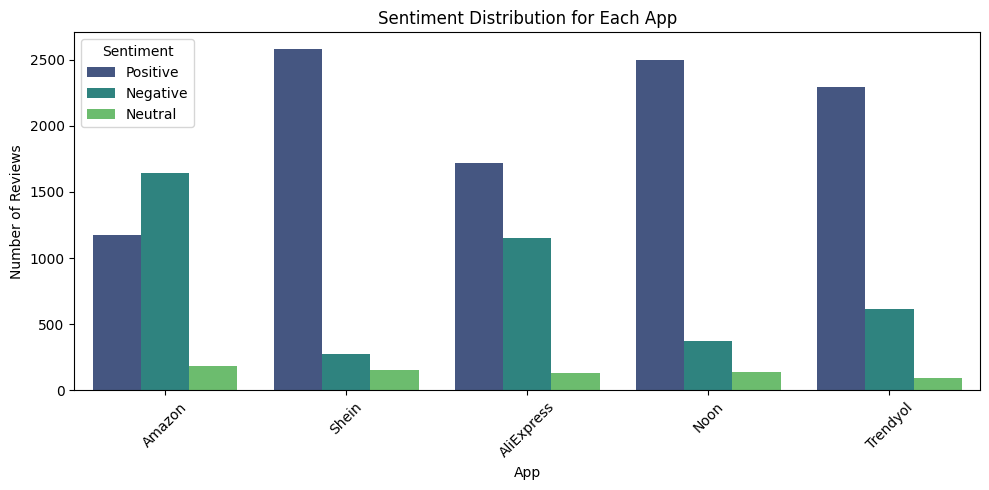

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

df_before = df.copy()
plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_before,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [44]:
print ("Before: \n", df_before["sentiment_label"]. value_counts ())

Before: 
 sentiment_label
Positive    10250
Negative     4053
Neutral       697
Name: count, dtype: int64


In [45]:
df = df[df["review_text"].astype(str).str.contains(r"[A-Za-z]", na=False)].copy()
df["review_text"] = df["review_text"].astype(str)
df = df[df["review_text"].str.strip().ne("")].copy()

print("After language/empty filtering:", len(df))

After language/empty filtering: 14441


In [46]:
import re



def clean_text(text):

    text = re.sub(r"http\S+", "", str(text))

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = text.lower()

    return text



df["clean_review"] = df["review_text"].apply(clean_text)

In [47]:
df.to_csv("google_play_app_reviews.csv", index=False)

In [48]:
df[["review_text", "clean_review"]].head(10)

,review_text,clean_review
0,it's very convenient and you deliver when you ...,its very convenient and you deliver when you s...
1,keeps getting stuck,keeps getting stuck
2,Excellent,excellent
3,paid extra for expedited shipping.. didnt arri...,paid extra for expedited shipping didnt arrive...
4,The worst customer service ever in Egypt. They...,the worst customer service ever in egypt they ...
5,I was hacked people are still trying to get or...,i was hacked people are still trying to get or...
6,Les services et le support sont devenus vraime...,les services et le support sont devenus vraime...
7,Can't open app,cant open app
8,3 of the last 4 orders have been lost in trans...,of the last orders have been lost in transit...
9,Convenient for my shopping needs ✅️,convenient for my shopping needs


In [49]:
import nltk
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [50]:
df["Tokens"]= df["clean_review"].apply(word_tokenize)
df[[ "clean_review","Tokens"]].head(5)

,clean_review,Tokens
0,its very convenient and you deliver when you s...,"[its, very, convenient, and, you, deliver, whe..."
1,keeps getting stuck,"[keeps, getting, stuck]"
2,excellent,[excellent]
3,paid extra for expedited shipping didnt arrive...,"[paid, extra, for, expedited, shipping, didnt,..."
4,the worst customer service ever in egypt they ...,"[the, worst, customer, service, ever, in, egyp..."


In [51]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

r
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df["Tokens_No_Stopwords"] = df["Tokens"].apply(remove_stopwords)


def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df["Tokens_No_Stopwords_Lemmatized"] = df["Tokens_No_Stopwords"].apply(lemmatize_tokens)


df[["Tokens", "Tokens_No_Stopwords", "Tokens_No_Stopwords_Lemmatized"]].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Tokens,Tokens_No_Stopwords,Tokens_No_Stopwords_Lemmatized
0,"[its, very, convenient, and, you, deliver, whe...","[convenient, deliver, say]","[convenient, deliver, say]"
1,"[keeps, getting, stuck]","[keeps, getting, stuck]","[keep, getting, stuck]"
2,[excellent],[excellent],[excellent]
3,"[paid, extra, for, expedited, shipping, didnt,...","[paid, extra, expedited, shipping, didnt, arri...","[paid, extra, expedited, shipping, didnt, arri..."
4,"[the, worst, customer, service, ever, in, egyp...","[worst, customer, service, ever, egypt, useles...","[worst, customer, service, ever, egypt, useles..."


In [52]:
df['tokens_str'] = df['Tokens_No_Stopwords_Lemmatized'].apply(lambda x: ' '.join(x))
df = df.drop_duplicates(subset='tokens_str', keep='first')

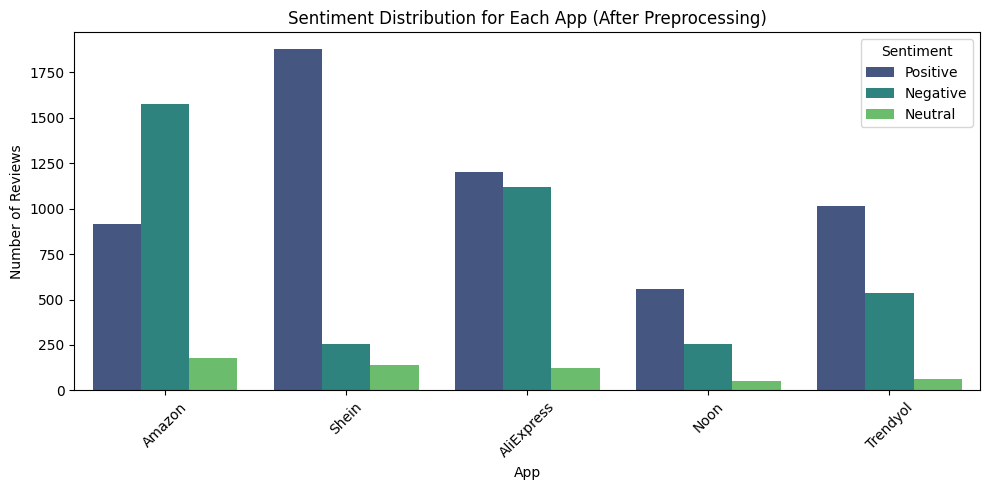

In [53]:
df_after = df.copy()

plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_after,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App (After Preprocessing)")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [54]:

print("\nAfter:\n", df_after["sentiment_label"].value_counts() )


After:
 sentiment_label
Positive    5567
Negative    3742
Neutral      554
Name: count, dtype: int64


In [55]:
df.to_csv("google_play_app_reviews.csv", index=False)

In [56]:
from google.colab import files
files.download("google_play_app_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
!pip install gensim

In [58]:
X_text = df['tokens_str']
y = df['sentiment_label']

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from gensim.models import Word2Vec
import numpy as np


X_train_tokens = [text.split() for text in X_train_text]
X_test_tokens = [text.split() for text in X_test_text]

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

def get_sentence_vector(tokens, model, vector_size):
  vectors = [model.wv[word] for word in tokens if word in model.wv]

  if len(vectors) ==0:
    return np.zeros(vector_size)

  return np.mean(vectors, axis=0)

X_train = np.array([get_sentence_vector(tokens, w2v_model, 100)for tokens in X_train_tokens])
X_test = np.array([get_sentence_vector(tokens, w2v_model, 100) for tokens in X_test_tokens])

In [59]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: sentiment_label
Positive    4453
Negative    2994
Neutral      443
Name: count, dtype: int64
After SMOTE: sentiment_label
Positive    4453
Negative    4453
Neutral     4453
Name: count, dtype: int64


In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_resampled, y_train_resampled)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Classification Report:\n", classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.7759756715661429
Classification Report:
               precision    recall  f1-score   support

    Negative       0.72      0.83      0.77       748
     Neutral       0.12      0.09      0.10       111
    Positive       0.88      0.81      0.84      1114

    accuracy                           0.78      1973
   macro avg       0.57      0.58      0.57      1973
weighted avg       0.77      0.78      0.77      1973



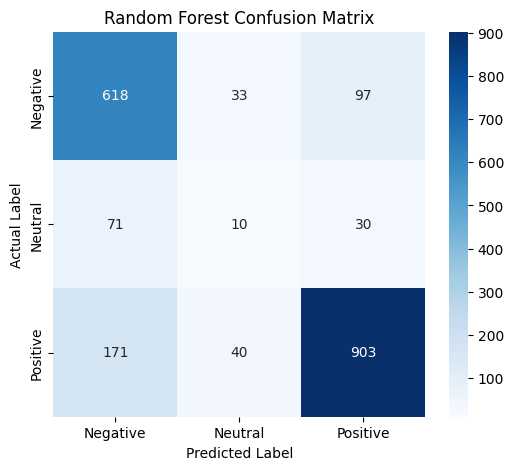

In [61]:

cm_rf = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [62]:
from sklearn.tree import DecisionTreeClassifier




dt_model = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)

dt_model.fit(X_train_resampled, y_train_resampled)


y_pred = dt_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6741003547896605

Classification Report:

              precision    recall  f1-score   support

    Negative       0.67      0.64      0.66       748
     Neutral       0.09      0.21      0.12       111
    Positive       0.83      0.74      0.78      1114

    accuracy                           0.67      1973
   macro avg       0.53      0.53      0.52      1973
weighted avg       0.73      0.67      0.70      1973

Confusion Matrix:
 [[481 124 143]
 [ 57  23  31]
 [178 110 826]]


In [68]:

from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_resampled, y_train_resampled)

y_pred_SVM = svm_model.predict(X_test)


print("SVM Accuracy:", accuracy_score(y_test, y_pred_SVM))
print("\nClassification Report:\n", classification_report(y_test, y_pred_SVM))


SVM Accuracy: 0.7247845919918905

Classification Report:
               precision    recall  f1-score   support

    Negative       0.76      0.73      0.74       748
     Neutral       0.11      0.34      0.17       111
    Positive       0.93      0.76      0.83      1114

    accuracy                           0.72      1973
   macro avg       0.60      0.61      0.58      1973
weighted avg       0.82      0.72      0.76      1973



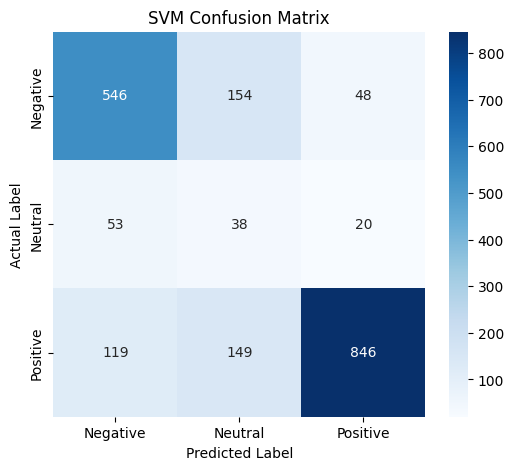

In [69]:
cm_svm = confusion_matrix(y_test, y_pred_SVM)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Confusion Matrix")
plt.show()

In [66]:
from sklearn.naive_bayes import GaussianNB


nb_model = GaussianNB()


nb_model.fit(X_train_resampled, y_train_resampled)


y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6320324379118094

Classification Report:
               precision    recall  f1-score   support

    Negative       0.67      0.80      0.73       748
     Neutral       0.05      0.14      0.07       111
    Positive       0.86      0.57      0.68      1114

    accuracy                           0.63      1973
   macro avg       0.53      0.50      0.49      1973
weighted avg       0.74      0.63      0.67      1973

Confusion Matrix:
 [[598  69  81]
 [ 71  16  24]
 [219 262 633]]


In [67]:
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder



le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)


xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train_encoded)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_encoded, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:27:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8084135833755702

Classification Report:

              precision    recall  f1-score   support

    Negative       0.75      0.83      0.79       748
     Neutral       0.00      0.00      0.00       111
    Positive       0.85      0.88      0.86      1114

    accuracy                           0.81      1973
   macro avg       0.53      0.57      0.55      1973
weighted avg       0.77      0.81      0.79      1973

Confusion Matrix:

[[619   1 128]
 [ 68   0  43]
 [136   2 976]]
